In [42]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [43]:
# open the HDF5 file
with h5py.File("/data/jihenghu/miro/miro_L4_cts_10min_2014217.h5") as h:
    vlos = h["velocity/b0"][:]            # km/s, positive = red-shifted (receding)
    TA   = h["spectra/b0/TA"][:]          # (1008, 338), continuum removed
    err  = h["spectra/b0/TA_err"][:]
    cont = h["continuum/TA_submm"][:]
    utc  = h["time/utc_mid"][:]
    dist = h["geometry/DIST"][:]          # comet centre -> spacecraft, km
    RH   = h["geometry/RH"][:]            # comet -> Sun, AU
    bimp = h["geometry/IMPACT_PARAM"][:]  # LOS impact parameter, km
    Rscene = h["geometry/SCENE_R"][:]     # nucleus radius at the beam footprint, km

# list the shape of the datasets
print("vlos shape:", vlos.shape)
print("TA shape:", TA.shape)
print("err shape:", err.shape)
print("cont shape:", cont.shape)
print("utc shape:", utc.shape)


vlos shape: (338,)
TA shape: (1008, 338)
err shape: (1008, 338)
cont shape: (1008,)
utc shape: (1008,)


In [44]:
# calculate the frequency bins from the velocity bins
c = 299792458.0  # speed of light in m/s
# Assuming the rest frequency of the water line is 556.936 GHz
rest_freq = 556.936e9  # in Hz
# vlos is in km/s -> convert to m/s before applying the Doppler shift
freq_bins = rest_freq * (1 - vlos * 1.0e3 / c)

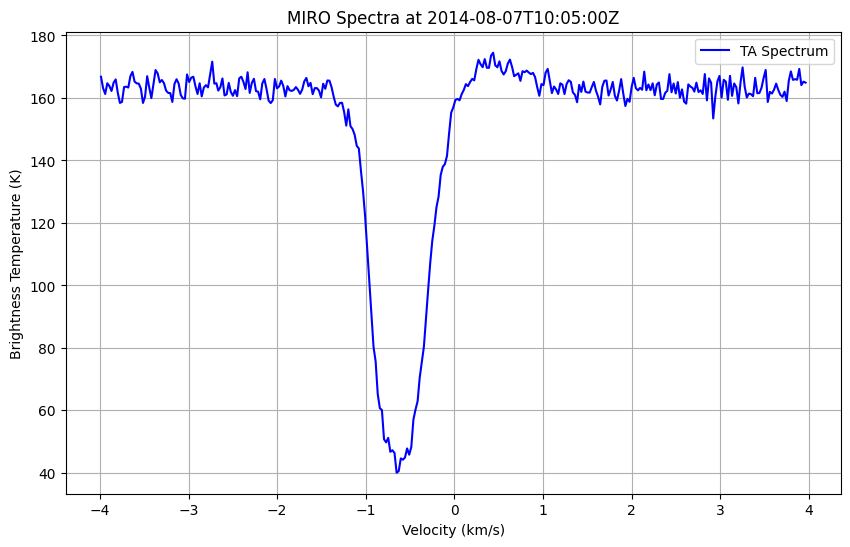

In [45]:
# plot the spectra at time step at 2014-08-07T10:00:00Z

# find the index of the time step
time_index = np.where(utc ==b'2014-08-07T10:05:00Z')[0][0]

TA_spectrum=TA[time_index]
Cont_spectrum=cont[time_index]

plt.figure(figsize=(10, 6))
plt.plot(vlos, TA_spectrum+Cont_spectrum, label='TA Spectrum', color='blue')
# plt.plot(vlos, Cont_spectrum, label='Continuum Spectrum', color='orange')


plt.xlabel('Velocity (km/s)')
plt.ylabel('Brightness Temperature (K)')
plt.title('MIRO Spectra at 2014-08-07T10:05:00Z')
plt.legend()
plt.grid()
plt.show()



---
# Retrieval of the coma parameters from the 556.936 GHz H$_2$O line

The beam looks straight down at the nucleus, so the line of sight starts on the
**nucleus surface** and ends at the spacecraft.  The forward model is the one used in
`examples/example_escapeRT.ipynb`: an escape-probability + two-level statistical
equilibrium iteration gives $n_l(r)$, $n_u(r)$, $\tau(r)$ and $S_\nu(r)$ for every coma
shell, and those are integrated along the line of sight to give $T_b$ per frequency bin.

Five parameters are tuned against the 338 observed bins:

| parameter | enters through | meaning |
|---|---|---|
| $Q$ | `calc_density(Q, r, v, r_h)` | water production rate, s$^{-1}$ |
| $a$ | `temperature_inverse_distance(r, a, b, t0, r0)` | inner $1/r$ temperature amplitude |
| $b$ | same | asymptotic temperature floor |
| $c$ | `velocity_tanh(r, v0, c)` | acceleration scale length, m |
| $v_0$ | same | terminal expansion velocity, m s$^{-1}$ |

With `t0 = 1 K` and `r0 = 1000 m` held fixed the kinetic profile is
$T(r) = a\,(1\,\mathrm{km}/r) + b$ in kelvin, so $a$ and $b$ are directly readable and
non-degenerate (`t0` only multiplies both).

**Radiation boundaries.**  The isotropic background that drives the excitation is the
**CMB, 2.725 K**.  The *line-of-sight* background is the nucleus surface, whose brightness
temperature is read off the measured continuum `continuum/TA_submm`.  We take $T_A \equiv T_b$;
the submm beam (FWHM $\approx 7.5'$, i.e. $\approx 0.19$ km at 85 km) is far smaller than the
nucleus disc, so it is completely filled and no beam convolution is needed.

In [46]:
import sys
import time
sys.path.append('../../')

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

import Constants as constants
from ComaGrid import ComaGrid
from Einstein_coeff import einstein_coeffs_B
from Electron_collision import electron_collision_rate
from Molecular_collision import detailed_balance_excitation_rate, molecular_collision_rate
from profiles import calc_density, temperature_inverse_distance, electron_biver_1997, velocity_tanh
from Solar_pumping import scale_g_factors_from_1au
from Statistical_equilibrium import monte_carlo_two_level_populations
from escape_probability_RTsolver import solve_escape_probability_layers
from NonLTE_optics import nonlte_source_function

C_LIGHT = constants.SPEED_OF_LIGHT
H_PLANCK = constants.PLANCK_CONSTANT
K_B = constants.BOLTZMANN_CONSTANT

# 1_10 -> 1_01 ortho-water ground rotational transition
NU0_HZ = 556.936e9
A_UL_S1 = 3.456e-3
G_U = 9.0
G_L = 9.0
M_H2O_KG = 18.01528 * constants.ATOMIC_MASS_UNIT

T_CMB_K = 2.725


def planck_intensity(temperature_K, nu_Hz=NU0_HZ):
    """Planck specific intensity [W m^-2 Hz^-1 sr^-1]."""
    temperature_K = np.asarray(temperature_K, dtype=np.float64)
    return (2.0 * H_PLANCK * nu_Hz ** 3 / C_LIGHT ** 2) / np.expm1(
        H_PLANCK * nu_Hz / (K_B * temperature_K)
    )


def planck_brightness_temperature(intensity, nu_Hz=NU0_HZ):
    """Inverse of `planck_intensity`: intensity -> brightness temperature [K]."""
    intensity = np.maximum(np.asarray(intensity, dtype=np.float64), 1.0e-300)
    return (H_PLANCK * nu_Hz / K_B) / np.log1p(
        2.0 * H_PLANCK * nu_Hz ** 3 / C_LIGHT ** 2 / intensity
    )


I_CMB = float(planck_intensity(T_CMB_K))
print(f"CMB intensity at {NU0_HZ/1e9:.3f} GHz: {I_CMB:.4e} W m^-2 Hz^-1 sr^-1")

CMB intensity at 556.936 GHz: 1.4003e-19 W m^-2 Hz^-1 sr^-1


## 1. Observation and geometry for the selected time step

In [47]:
obs_utc = b'2014-08-07T10:05:00Z'
it_obs = int(np.where(utc == obs_utc)[0][0])

u_chan_m_s = vlos * 1.0e3                      # channel velocity, m/s (positive = receding)
ta_obs_K = TA[it_obs].astype(np.float64)       # continuum-removed line antenna temperature
ta_err_K = err[it_obs].astype(np.float64)
T_surface_K = float(cont[it_obs])              # nucleus surface Tb from the continuum

D_obs_m = float(dist[it_obs]) * 1.0e3          # spacecraft distance from comet centre
b_impact_m = float(bimp[it_obs]) * 1.0e3       # LOS impact parameter
R_nucleus_m = float(Rscene[it_obs]) * 1.0e3    # nucleus radius at the beam footprint
r_h_AU = float(RH[it_obs])

fit_mask = np.isfinite(ta_obs_K) & np.isfinite(ta_err_K) & (ta_err_K > 0.0)

print(f"UTC                     : {obs_utc.decode()}  (index {it_obs})")
print(f"Heliocentric distance   : {r_h_AU:.4f} AU")
print(f"Spacecraft distance     : {D_obs_m/1e3:.3f} km")
print(f"LOS impact parameter    : {b_impact_m/1e3:.4f} km")
print(f"Nucleus radius at beam  : {R_nucleus_m/1e3:.4f} km")
print(f"Surface Tb (continuum)  : {T_surface_K:.2f} K")
print(f"Channels used / total   : {fit_mask.sum()} / {u_chan_m_s.size}")
print(f"Deepest absorption      : {np.nanmin(ta_obs_K):.2f} K "
      f"at {u_chan_m_s[np.nanargmin(ta_obs_K)]:.1f} m/s")
print(f"Median channel error    : {np.nanmedian(ta_err_K):.2f} K")

UTC                     : 2014-08-07T10:05:00Z  (index 348)
Heliocentric distance   : 3.5927 AU
Spacecraft distance     : 85.443 km
LOS impact parameter    : 0.4333 km
Nucleus radius at beam  : 1.6938 km
Surface Tb (continuum)  : 163.00 K
Channels used / total   : 337 / 338
Deepest absorption      : -122.96 K at -651.6 m/s
Median channel error    : 2.23 K


## 2. Forward model

### 2a. Coma structure and non-LTE excitation

Identical to `example_escapeRT.ipynb`: iterate the escape-probability RT update
(`solve_escape_probability_layers`, LVG-sphere $\beta$) against two-level statistical
equilibrium until the layer mean intensity $J_\nu$ stops changing.

The statistical-equilibrium step is written out analytically here.  It is the *same fixed
point* that `monte_carlo_two_level_populations` walks towards (`target_n_u` in that
function), but it is noiseless and ~6x faster, which matters because the least-squares
Jacobian is built from finite differences.  Set `use_monte_carlo=True` to call the repo
routine instead — the two agree to $\sim2\times10^{-9}$ in $n_u$.

In [48]:
def build_radial_grid(r_min_m, r_max_m, nlayer):
    """Log-spaced cell centres `xc` with geometric-mean faces `xf`, as in the RT examples."""
    xc = np.logspace(np.log10(r_min_m), np.log10(r_max_m), nlayer)
    xf = np.empty(nlayer + 1, dtype=np.float64)
    xf[1:-1] = np.sqrt(xc[:-1] * xc[1:])
    xf[0] = xc[0] ** 2 / xf[1]
    xf[-1] = xc[-1] ** 2 / xf[-2]
    return xc, xf


def solve_coma_excitation(
    Q, a, b, c_scale_m, v0_m_s, *,
    xc, xf, r_h_AU,
    t0_K=1.0, r0_m=1000.0,
    geometry='LVG sphere',
    background_intensity=I_CMB,
    max_rt_iterations=300,
    jv_rtol=1.0e-6,
    use_monte_carlo=False,
    random_seed=7,
):
    """Return (coma, rt_result, n_iterations) for one set of the five parameters."""
    nlayer = xc.size

    velocity = velocity_tanh(xc, v0=v0_m_s, c=c_scale_m)
    temperature = temperature_inverse_distance(xc, a=a, b=b, t0=t0_K, r0=r0_m)
    total_number_density = calc_density(
        Q, xc, velocity, r_h=r_h_AU, model_type='isotropic', photo_dissociation=True,
    )
    nelec, telec = electron_biver_1997(
        Q, r_h=r_h_AU, r=xc, v=velocity, t_kin=temperature, t_emax=10000,
    )

    coma = ComaGrid(
        temperature=temperature,
        total_number_density=total_number_density,
        velocity=velocity,
        nelec=nelec,
        telec=telec,
        fractions=np.zeros((nlayer, 1), dtype=np.float64),   # start fully in the lower level
    )
    coma.xc = xc
    coma.xf = xf

    B_ul_SI, B_lu_SI = einstein_coeffs_B(nu_Hz=NU0_HZ, A_ul_s_1=A_UL_S1, g_u=G_U, g_l=G_L)
    Cm_ul = np.asarray(
        molecular_collision_rate(coma.total_number_density, coma.temperature), dtype=np.float64
    )
    Cm_lu = np.asarray(
        detailed_balance_excitation_rate(
            Cm_ul, coma.temperature, nu_Hz=NU0_HZ, g_u=G_U, g_l=G_L
        ), dtype=np.float64,
    )
    electron_rates = np.array([
        electron_collision_rate(
            n_e=float(n_e), t_e=float(t_e), nu_Hz=NU0_HZ,
            A_ul_s_1=A_UL_S1, g_u=G_U, g_l=G_L,
        )
        for n_e, t_e in zip(coma.nelec, coma.telec)
    ], dtype=np.float64)
    Ce_ul, Ce_lu = electron_rates[:, 0], electron_rates[:, 1]

    g_ul, g_lu = scale_g_factors_from_1au(r_h_AU)
    G_ul = np.full(nlayer, g_ul, dtype=np.float64)
    G_lu = np.full(nlayer, g_lu, dtype=np.float64)

    previous_jv = None
    rt_result = None
    for iteration in range(1, max_rt_iterations + 1):
        rt_result = solve_escape_probability_layers(
            coma, lower_level=0, upper_level=1,
            nu_Hz=NU0_HZ, A_ul_s_1=A_UL_S1, g_u=G_U, g_l=G_L,
            absorber_mass_kg=M_H2O_KG,
            background_intensity=background_intensity,
            geometry=geometry,
        )
        jv = np.asarray(rt_result['J_v_stream_average'], dtype=np.float64)

        if previous_jv is not None:
            scale = np.maximum.reduce((np.abs(previous_jv), np.abs(jv), np.full_like(jv, 1.0e-34)))
            if np.max(np.abs(jv - previous_jv) / scale) < jv_rtol:
                return coma, rt_result, iteration

        if use_monte_carlo:
            monte_carlo_two_level_populations(
                coma, jv,
                A_ul_s_1=A_UL_S1, B_ul_SI=B_ul_SI, B_lu_SI=B_lu_SI,
                Cm_ul_s_1=Cm_ul, Cm_lu_s_1=Cm_lu,
                Ce_ul_s_1=Ce_ul, Ce_lu_s_1=Ce_lu,
                G_ul_s_1=G_ul, G_lu_s_1=G_lu,
                nu_Hz=NU0_HZ, g_u=G_U, g_l=G_L,
                max_iterations=20000, tolerance=1.0e-12,
                packet_fraction_range=(0.05, 0.35),
                random_seed=random_seed + iteration,
            )
        else:
            # n_u (A + B_ul J + Cm_ul + Ce_ul + G_ul) = n_l (B_lu J + Cm_lu + Ce_lu + G_lu)
            downward = A_UL_S1 + B_ul_SI * jv + Cm_ul + Ce_ul + G_ul
            upward = B_lu_SI * jv + Cm_lu + Ce_lu + G_lu
            n_total = coma.density[:, 0] + coma.density[:, 1]
            n_upper = n_total * upward / (upward + downward)
            coma.update_density_from_fractions(
                (n_upper / np.maximum(n_total, 1.0e-300))[:, np.newaxis]
            )

        previous_jv = jv

    return coma, rt_result, max_rt_iterations

### 2b. Line-of-sight integration

The ray runs from the nucleus surface ($r = R_\mathrm{nuc}$) out to the spacecraft
($r = D$), with impact parameter $p$.  Writing $z$ for the coordinate along the ray
measured from the point of closest approach, $z = \sqrt{r^2 - p^2}$ is positive and
monotonic over the whole path, so

$$\mathrm{d}s = \mathrm{d}z, \qquad \hat r\cdot\hat e = z/r .$$

The gas at radius $r$ expands radially at $v(r)$, so its velocity **towards the observer**
is $v(r)\,z/r$; in the "positive = receding" convention of the data its line-of-sight
velocity is $v_\mathrm{los} = -v(r)\,z/r$.  Every parcel between the nucleus and the
spacecraft is therefore approaching, which is why the whole absorption sits on the
blue-shifted side of the spectrum.

Per segment, with the thermal width $u_\mathrm{th} = \sqrt{2kT/m}$ and the same
non-LTE coefficients used by `NonLTE_optics.nonlte_tau`:

$$\alpha_\nu = \frac{c^2}{8\pi\nu_0^2}A_{ul}\left(\frac{g_u}{g_l}n_l - n_u\right)\phi_\nu,
\qquad
\phi_\nu = \frac{\exp[-((u - v_\mathrm{los})/u_\mathrm{th})^2]}{\sqrt{\pi}\,\nu_0 u_\mathrm{th}/c}.$$

Then the ray is integrated outward from the surface,
$I_\nu = I_\mathrm{surf}e^{-\tau_\mathrm{tot}} + \sum_k S_k\,(1-e^{-\Delta\tau_k})\,e^{-\tau_k^{\rm above}}$.

In [49]:
def los_brightness(
    coma, u_chan_m_s, *,
    R_nucleus_m, b_impact_m, D_obs_m, surface_intensity,
    n_segments=600,
    return_layers=False,
):
    """Brightness of the nadir ray for every channel velocity.

    Returns `(intensity, tau_total)`, or additionally a per-segment breakdown when
    `return_layers=True` (the `T_b` contribution of each coma cell, as in the
    forward-modelling example).
    """
    r_edges = np.logspace(np.log10(R_nucleus_m), np.log10(D_obs_m), n_segments + 1)
    r_mid = np.sqrt(r_edges[:-1] * r_edges[1:])

    # z from the closest-approach point; positive and monotonic along the whole path
    z_edges = np.sqrt(np.maximum(r_edges ** 2 - b_impact_m ** 2, 0.0))
    ds_m = np.diff(z_edges)
    mu = np.sqrt(np.maximum(r_mid ** 2 - b_impact_m ** 2, 0.0)) / r_mid   # r_hat . e_hat

    log_xc = np.log(coma.xc)
    lin = lambda y: np.interp(np.log(r_mid), log_xc, y)
    log = lambda y: np.exp(np.interp(np.log(r_mid), log_xc, np.log(np.maximum(y, 1.0e-300))))

    n_lower = log(coma.density[:, 0])
    n_upper = log(coma.density[:, 1])
    temperature = lin(coma.temperature)
    velocity = lin(coma.velocity)
    source = log(nonlte_source_function(coma, lower_level=0, upper_level=1,
                                        nu_Hz=NU0_HZ, g_u=G_U, g_l=G_L))

    v_los = -velocity * mu                            # positive = receding
    u_thermal = np.sqrt(2.0 * K_B * temperature / M_H2O_KG)
    delta_nu_D = NU0_HZ * u_thermal / C_LIGHT

    x = (u_chan_m_s[:, None] - v_los[None, :]) / u_thermal[None, :]
    phi_nu = np.exp(-x ** 2) / (np.sqrt(np.pi) * delta_nu_D[None, :])
    alpha = (C_LIGHT ** 2 / (8.0 * np.pi * NU0_HZ ** 2)) * A_UL_S1 * (
        (G_U / G_L) * n_lower - n_upper
    )[None, :] * phi_nu
    d_tau = alpha * ds_m[None, :]

    cum_tau = np.cumsum(d_tau, axis=1)                # from the surface outward
    tau_total = cum_tau[:, -1]
    tau_above = tau_total[:, None] - cum_tau          # between the segment and the observer

    layer_emission = source[None, :] * (-np.expm1(-d_tau)) * np.exp(-tau_above)
    intensity = surface_intensity * np.exp(-tau_total) + layer_emission.sum(axis=1)

    if return_layers:
        return intensity, tau_total, {
            'r_mid_m': r_mid,
            'ds_m': ds_m,
            'd_tau': d_tau,
            'tau_above': tau_above,
            'layer_emission': layer_emission,
            'source_function': source,
            'v_los_m_s': v_los,
            'temperature_K': temperature,
            'n_lower': n_lower,
            'n_upper': n_upper,
        }
    return intensity, tau_total

### 2c. Wrapping it up: five parameters $\rightarrow$ 338 modelled channels

In [50]:
# Radial grid: from the nucleus surface out well past the spacecraft.
# Only gas between the surface and the spacecraft is on the line of sight, but the
# escape-probability update is purely local, so extra outer shells cost nothing.
N_LAYER = 64
R_MAX_M = 1.0e7
xc_grid, xf_grid = build_radial_grid(R_nucleus_m, R_MAX_M, N_LAYER)
I_SURFACE = float(planck_intensity(T_surface_K))

PARAM_NAMES = ['log10 Q', 'a [K]', 'b [K]', 'log10 c [m]', 'v0 [m/s]']


def unpack(theta):
    """(log10 Q, a, b, log10 c, v0) -> physical values."""
    return 10.0 ** theta[0], theta[1], theta[2], 10.0 ** theta[3], theta[4]


def forward_model(theta, u_channels=None, *, return_state=False):
    """Modelled continuum-removed line spectrum, i.e. Tb(u) - T_surface."""
    if u_channels is None:
        u_channels = u_chan_m_s
    Q, a, b, c_scale, v0 = unpack(theta)
    coma, rt_result, n_iter = solve_coma_excitation(
        Q, a, b, c_scale, v0, xc=xc_grid, xf=xf_grid, r_h_AU=r_h_AU,
    )
    out = los_brightness(
        coma, u_channels,
        R_nucleus_m=R_nucleus_m, b_impact_m=b_impact_m, D_obs_m=D_obs_m,
        surface_intensity=I_SURFACE, return_layers=return_state,
    )
    intensity, tau_total = out[0], out[1]
    delta_tb = planck_brightness_temperature(intensity) - T_surface_K
    if return_state:
        return delta_tb, {'coma': coma, 'rt': rt_result, 'n_iter': n_iter,
                          'tau_total': tau_total, 'layers': out[2]}
    return delta_tb


def residuals(theta):
    model = forward_model(theta, u_chan_m_s[fit_mask])
    return (model - ta_obs_K[fit_mask]) / ta_err_K[fit_mask]


# quick sanity check with a first guess
theta_guess = np.array([26.0, 120.0, 15.0, np.log10(5.3e3), 700.0])
t_start = time.perf_counter()
model_guess = forward_model(theta_guess)
print(f"one forward model: {time.perf_counter() - t_start:.3f} s")
print(f"first guess -> deepest model dTb = {model_guess.min():.1f} K "
      f"(observed {np.nanmin(ta_obs_K):.1f} K)")

one forward model: 0.016 s
first guess -> deepest model dTb = -147.9 K (observed -123.0 K)


## 3. Fit the 338 bins

`least_squares` (Trust Region Reflective) on the $\chi$ vector
$(\hat T_A - T_A)/\sigma_{T_A}$.  A short multi-start is run first because the
five parameters are correlated; in practice the same minimum is reached from the large
majority of random starts.

In [51]:
lower_bounds = np.array([24.0,    1.0,   1.0, 2.0,  200.0])
upper_bounds = np.array([28.0, 3000.0, 300.0, 5.5, 1200.0])

FIT_KWARGS = dict(bounds=(lower_bounds, upper_bounds), diff_step=1e-3,
                  xtol=1e-12, ftol=1e-12, max_nfev=400)

N_STARTS = 12          # set to 0 to fit only from `theta_guess`
rng = np.random.default_rng(0)

starts = [theta_guess]
for _ in range(N_STARTS):
    starts.append(np.array([
        rng.uniform(24.5, 27.0),
        10.0 ** rng.uniform(0.5, 3.0),
        10.0 ** rng.uniform(0.0, 2.2),
        rng.uniform(2.5, 5.0),
        rng.uniform(300.0, 1000.0),
    ]))

dof = int(fit_mask.sum()) - len(PARAM_NAMES)
best = None
for k, start in enumerate(starts):
    try:
        result = least_squares(residuals, start, **FIT_KWARGS)
    except Exception as exc:                      # non-physical corners of parameter space
        print(f"start {k:2d}: failed ({exc})")
        continue
    chi2_red = float(np.sum(result.fun ** 2) / dof)
    Q, a, b, c_scale, v0 = unpack(result.x)
    print(f"start {k:2d}: chi2/dof={chi2_red:8.4f}  Q={Q:.3e}  a={a:8.2f}  "
          f"b={b:7.2f}  c={c_scale:9.4g}  v0={v0:7.1f}")
    if best is None or chi2_red < best[0]:
        best = (chi2_red, result)

chi2_red, fit = best
theta_fit = fit.x
Q_fit, a_fit, b_fit, c_fit, v0_fit = unpack(theta_fit)

start  0: chi2/dof=  2.1183  Q=8.326e+24  a=  243.58  b=  74.03  c=     7076  v0=  667.7
start  1: chi2/dof=  2.1183  Q=8.326e+24  a=  243.58  b=  74.03  c=     7076  v0=  667.7
start  2: chi2/dof=  2.1183  Q=8.326e+24  a=  243.58  b=  74.03  c=     7076  v0=  667.7
start  3: chi2/dof=  2.1183  Q=8.326e+24  a=  243.48  b=  74.05  c=     7070  v0=  667.6
start  4: chi2/dof=  3.0023  Q=6.727e+24  a=  122.78  b=  87.03  c=    104.1  v0=  620.6
start  5: chi2/dof=  2.8274  Q=4.133e+24  a=   25.78  b=  82.37  c=     2211  v0=  658.6
start  6: chi2/dof=  2.1183  Q=8.326e+24  a=  243.58  b=  74.03  c=     7076  v0=  667.7
start  7: chi2/dof=  3.0023  Q=6.732e+24  a=  122.96  b=  87.03  c=    163.4  v0=  620.6
start  8: chi2/dof=  2.1183  Q=8.326e+24  a=  243.58  b=  74.03  c=     7076  v0=  667.7
start  9: chi2/dof=  2.1183  Q=8.326e+24  a=  243.58  b=  74.03  c=     7076  v0=  667.7
start 10: chi2/dof=  2.8274  Q=4.133e+24  a=   25.77  b=  82.38  c=     2211  v0=  658.6
start 11: chi2/dof=  

In [52]:
# 1-sigma errors from the Gauss-Newton covariance, scaled by the reduced chi2
jac = fit.jac
covariance = np.linalg.inv(jac.T @ jac) * chi2_red
sigma = np.sqrt(np.diag(covariance))
correlation = covariance / np.outer(sigma, sigma)

model_fit = forward_model(theta_fit)
rms_K = float(np.sqrt(np.mean((model_fit[fit_mask] - ta_obs_K[fit_mask]) ** 2)))

print("=" * 62)
print(f"Best fit   chi2/dof = {chi2_red:.4f}   residual RMS = {rms_K:.2f} K "
      f"(baseline rms {np.nanmedian(ta_err_K):.2f} K)")
print("=" * 62)
print(f"  Q  = {Q_fit:.4e}  +/- {Q_fit*np.log(10)*sigma[0]:.3e}  s^-1")
print(f"  a  = {a_fit:8.2f}  +/- {sigma[1]:.2f}   K   (T = a*1km/r + b)")
print(f"  b  = {b_fit:8.2f}  +/- {sigma[2]:.2f}   K")
print(f"  c  = {c_fit:.4e}  +/- {c_fit*np.log(10)*sigma[3]:.3e}  m")
print(f"  v0 = {v0_fit:8.2f}  +/- {sigma[4]:.2f}   m/s")
print()
print("correlation matrix")
print("            " + "".join(f"{n:>13s}" for n in PARAM_NAMES))
for i, name in enumerate(PARAM_NAMES):
    print(f"{name:>12s}" + "".join(f"{correlation[i, j]:13.2f}" for j in range(5)))

Best fit   chi2/dof = 2.1183   residual RMS = 2.99 K (baseline rms 2.23 K)
  Q  = 8.3264e+24  +/- 2.511e+23  s^-1
  a  =   243.48  +/- 6.85   K   (T = a*1km/r + b)
  b  =    74.05  +/- 2.38   K
  c  = 7.0697e+03  +/- 2.504e+02  m
  v0 =   667.63  +/- 4.10   m/s

correlation matrix
                  log10 Q        a [K]        b [K]  log10 c [m]     v0 [m/s]
     log10 Q         1.00        -0.50         0.69        -0.31        -0.44
       a [K]        -0.50         1.00        -0.89         0.68         0.66
       b [K]         0.69        -0.89         1.00        -0.47        -0.65
 log10 c [m]        -0.31         0.68        -0.47         1.00         0.78
    v0 [m/s]        -0.44         0.66        -0.65         0.78         1.00


## 4. Fit quality

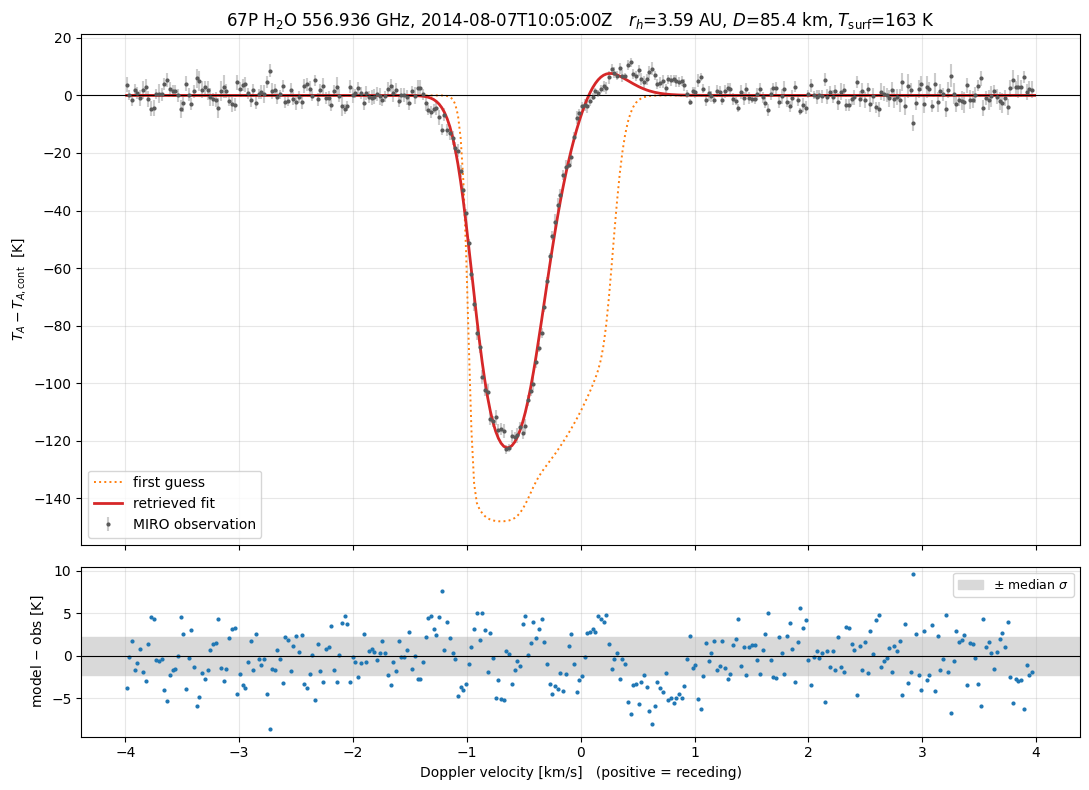

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

axes[0].errorbar(u_chan_m_s * 1e-3, ta_obs_K, yerr=ta_err_K, fmt='.', ms=4,
                 color='0.35', ecolor='0.8', label='MIRO observation')
axes[0].plot(u_chan_m_s * 1e-3, model_guess, ':', color='tab:orange', lw=1.4,
             label='first guess')
axes[0].plot(u_chan_m_s * 1e-3, model_fit, '-', color='tab:red', lw=2.0,
             label='retrieved fit')
axes[0].axhline(0.0, color='k', lw=0.8)
axes[0].set_ylabel(r'$T_A - T_{A,\mathrm{cont}}$  [K]')
axes[0].set_title(f'67P H$_2$O 556.936 GHz, {obs_utc.decode()}   '
                  f'$r_h$={r_h_AU:.2f} AU, $D$={D_obs_m/1e3:.1f} km, '
                  f'$T_\mathrm{{surf}}$={T_surface_K:.0f} K')
axes[0].legend()
axes[0].grid(alpha=0.3)

resid_K = model_fit - ta_obs_K
axes[1].axhspan(-np.nanmedian(ta_err_K), np.nanmedian(ta_err_K), color='0.85',
                label=r'$\pm$ median $\sigma$')
axes[1].plot(u_chan_m_s * 1e-3, resid_K, '.', ms=4, color='tab:blue')
axes[1].axhline(0.0, color='k', lw=0.8)
axes[1].set_xlabel('Doppler velocity [km/s]   (positive = receding)')
axes[1].set_ylabel('model $-$ obs [K]')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. The retrieved coma

escape-probability iterations: 7
line-centre optical depth to the nucleus: 3.8


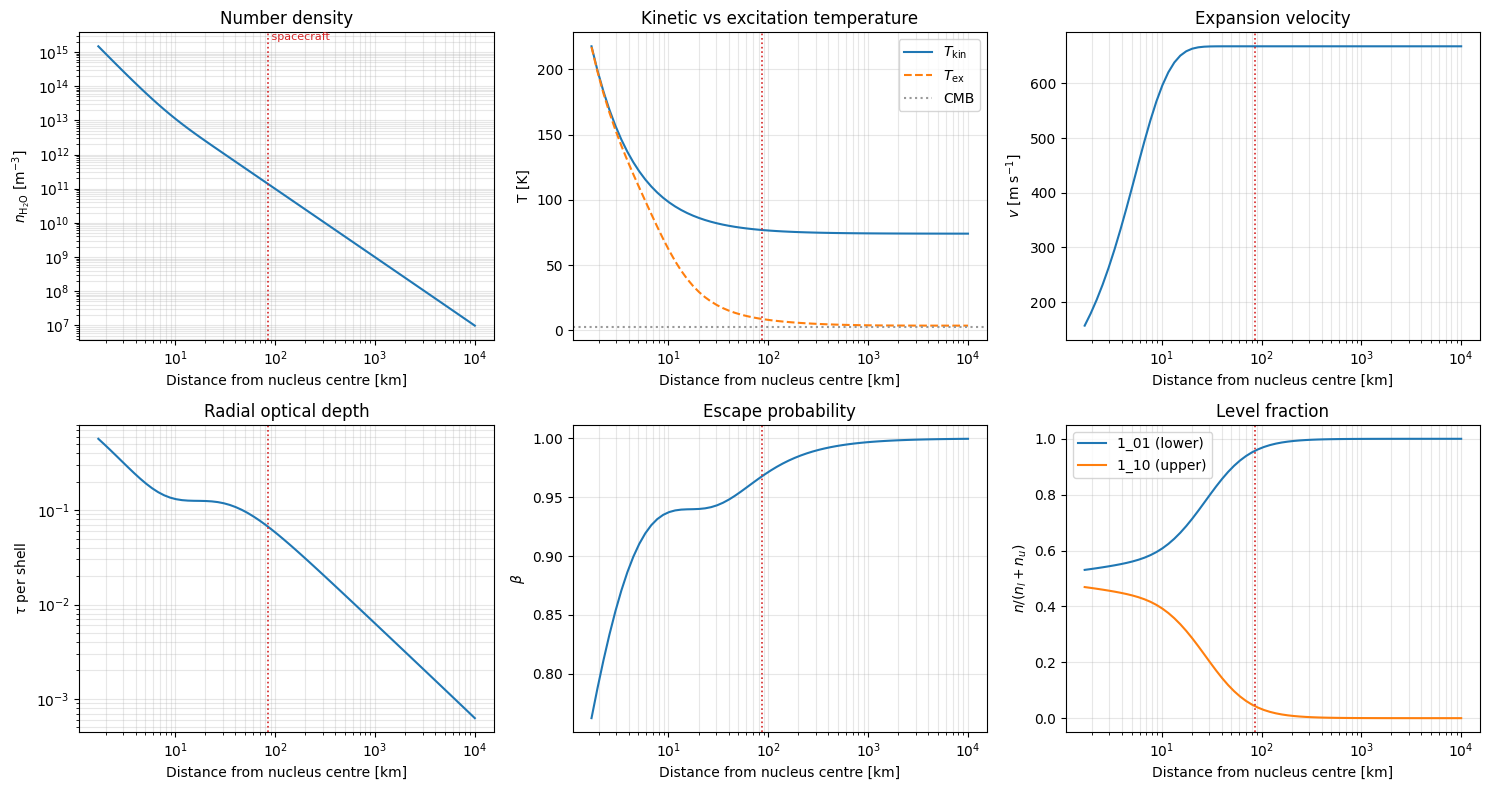

In [57]:
_, state = forward_model(theta_fit, u_chan_m_s, return_state=True)
coma_fit = state['coma']
rt_fit = state['rt']
layers = state['layers']
r_km = coma_fit.xc * 1e-3

print(f"escape-probability iterations: {state['n_iter']}")
print(f"line-centre optical depth to the nucleus: {state['tau_total'].max():.1f}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
ax = axes.flatten()

ax[0].loglog(r_km, coma_fit.total_number_density)
ax[0].set_ylabel(r'$n_{\rm H_2O}$ [m$^{-3}$]'); ax[0].set_title('Number density')

ax[1].semilogx(r_km, coma_fit.temperature, label=r'$T_{\rm kin}$')
ax[1].semilogx(r_km, np.asarray(rt_fit['excitation_temperature_K']), '--', label=r'$T_{\rm ex}$')
ax[1].axhline(T_CMB_K, color='0.6', ls=':', label='CMB')
ax[1].set_ylabel('T [K]'); ax[1].set_title('Kinetic vs excitation temperature')
ax[1].legend()

ax[2].semilogx(r_km, coma_fit.velocity)
ax[2].set_ylabel(r'$v$ [m s$^{-1}$]'); ax[2].set_title('Expansion velocity')

ax[3].loglog(r_km, np.maximum(np.asarray(rt_fit['tau_profile']), 1e-12))
ax[3].set_ylabel(r'$\tau$ per shell'); ax[3].set_title('Radial optical depth')

ax[4].semilogx(r_km, np.asarray(rt_fit['escape_probability']))
ax[4].set_ylabel(r'$\beta$'); ax[4].set_title('Escape probability')

n_tot = coma_fit.density[:, 0] + coma_fit.density[:, 1]
ax[5].semilogx(r_km, coma_fit.density[:, 0] / n_tot, label='1_01 (lower)')
ax[5].semilogx(r_km, coma_fit.density[:, 1] / n_tot, label='1_10 (upper)')
ax[5].set_ylabel(r'$n/(n_l+n_u)$'); ax[5].set_title('Level fraction')
ax[5].legend()

for a_ in ax:
    a_.set_xlabel('Distance from nucleus centre [km]')
    a_.axvline(D_obs_m / 1e3, color='tab:red', ls=':', lw=1.2)
    a_.grid(alpha=0.3, which='both')
ax[0].text(D_obs_m / 1e3, ax[0].get_ylim()[1], ' spacecraft', color='tab:red',
           va='top', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Where the signal comes from

Per-cell contribution to the emergent brightness: `layer_emission` is
$S_k(1-e^{-\Delta\tau_k})e^{-\tau_k^{\rm above}}$, i.e. exactly the term each coma cell
adds to the ray, and the attenuated surface term is what remains of the 163 K nucleus.

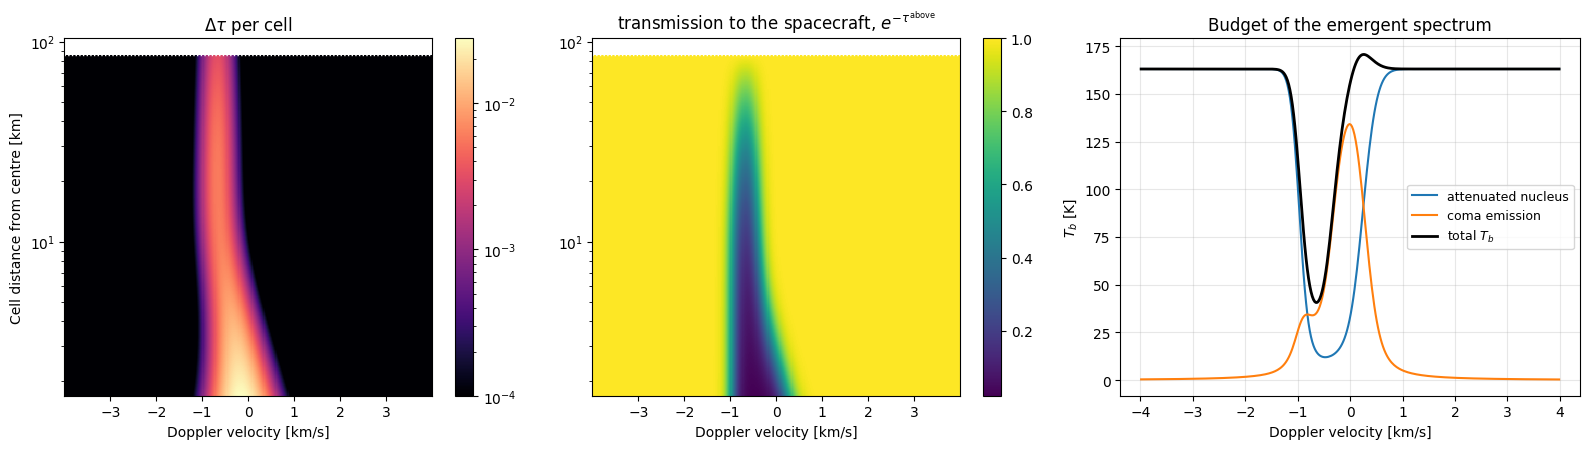

fraction of line-core tau inside    5.0 km: 0.296
fraction of line-core tau inside   10.0 km: 0.482
fraction of line-core tau inside   25.0 km: 0.735
fraction of line-core tau inside   50.0 km: 0.905
fraction of line-core tau inside   85.4 km: 1.000


In [55]:
r_seg_km = layers['r_mid_m'] * 1e-3
u_grid_km_s = u_chan_m_s * 1e-3

# cell contribution expressed as a brightness temperature increment
contrib_K = planck_brightness_temperature(
    np.maximum(layers['layer_emission'], 1e-300)
) * (layers['layer_emission'] > 1e-300)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

pc = axes[0].pcolormesh(u_grid_km_s, r_seg_km, layers['d_tau'].T,
                        shading='auto', cmap='magma',
                        norm=mpl.colors.LogNorm(vmin=1e-4,
                                                vmax=max(layers['d_tau'].max(), 1e-3)))
axes[0].set_yscale('log')
axes[0].set_ylabel('Cell distance from centre [km]')
axes[0].set_title(r'$\Delta\tau$ per cell')
fig.colorbar(pc, ax=axes[0])

pc = axes[1].pcolormesh(u_grid_km_s, r_seg_km,
                        np.exp(-layers['tau_above']).T, shading='auto', cmap='viridis')
axes[1].set_yscale('log')
axes[1].set_title(r'transmission to the spacecraft, $e^{-\tau^{\rm above}}$')
fig.colorbar(pc, ax=axes[1])

surface_term = planck_brightness_temperature(I_SURFACE * np.exp(-state['tau_total']))
axes[2].plot(u_grid_km_s, surface_term, label='attenuated nucleus')
axes[2].plot(u_grid_km_s, planck_brightness_temperature(
    np.maximum(layers['layer_emission'].sum(axis=1), 1e-300)), label='coma emission')
axes[2].plot(u_grid_km_s, model_fit + T_surface_K, 'k-', lw=2, label='total $T_b$')
axes[2].set_ylabel('$T_b$ [K]')
axes[2].set_title('Budget of the emergent spectrum')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

for a_ in axes[:2]:
    a_.axhline(D_obs_m / 1e3, color='w', ls=':', lw=1.0)
for a_ in axes:
    a_.set_xlabel('Doppler velocity [km/s]')

plt.tight_layout()
plt.show()

# how much of the absorbed column sits inside each decade of radius
tau_core = layers['d_tau'][np.nanargmin(model_fit)]   # cell-by-cell tau at the line core
cum_frac = np.cumsum(tau_core) / np.sum(tau_core)
for edge in (5.0, 10.0, 25.0, 50.0, D_obs_m / 1e3):
    print(f"fraction of line-core tau inside {edge:6.1f} km: "
          f"{np.interp(edge, r_seg_km, cum_frac):.3f}")